(finite-difference-method-section)=
# The finite-difference method

The finite-difference method solves a boundary value problem by approximating derivatives at a finite number of grid points. This converts the differential equation into a system of algebraic equations that can be solved using standard linear algebra techniques. Unlike the shooting method, which transforms a BVP into an IVP, the finite-difference method works directly with the boundary conditions.

Consider the equally spaced grid

$$ t_i = t_i + ih, \qquad i = 0, 1, \ldots, n, $$

where

$$ h = \frac{t_{\max} - t_0}{n},$$

or alternatively

$$ n = \frac{t_{\max} - t_0}{h}. $$

Let $y_i \approx y(t_i)$ then the derivatives of $y_i$ are approximated using values of neighbouring nodes $y_{i+1}$, $y_{i-1}$ etc. using expressions derived by truncating the Taylor series and rearranging to make the derivative term the subject. 

| Approximation | Error | Name
|:--:|:--:|:--:|
| $y'(t_i) \approx \dfrac{y_{i+1} - y_i}{h}$ | $O(h)$ | Forward difference |
| $y'(t_i) \approx \dfrac{y_i - y_{i-1}}{h}$ | $O(h)$ | Backward difference |
| $y'(t_i) \approx \dfrac{y_{i+1} - y_{i-1}}{2h}$ | $O(h^2)$ | Central difference |
| $y''(t_i) \approx \dfrac{y_{i-1} - 2 y_i + y_{i+1}}{h^2}$ | $O(h^2)$ | Symmetric difference |

The order of the error indicates how the approximation improves as the mesh is refined. For example, a second-order approximation has an error proportional to $h^2$, so halving the step size reduces the error by approximately a factor of four.

The solution to a boundary value problem using the finite-difference method is determined by approximating the derivatives in the ODE using finite-differences. Consider the following boundary value problem

$$ \begin{align*}
    y'' = f(t,y), \qquad t \in [t_0, t_{\max}], \qquad y(t_0) = a, \qquad y(t_{\max}) = b. 
\end{align*} $$

Replacing $y''$ by a finite-difference approximation at each interior node $t_i$, $i = 1, \ldots, n-1$, produces $n - 1$ algebraic equations. Together with the two boundary conditions $y_0 = a$ and $y_n = b$, this gives a total of $n + 1$ equations for the unknowns $y_0, \ldots, y_n$. 

````{prf:example}
:class: seealso
:label: bvp-finite-difference-example

Use the finite-difference method to solve the following boundary value problem using a step length of $h = 0.2$

$$ \begin{align*}
    y'' - y' - y = 0, \qquad y(0) = 0, \qquad y(1) = 2.
\end{align*} $$

---

**Solution**

The second-order central difference and symmetric difference approximations of $y'$ and $y''$ respectively are

$$ \begin{align*}
    y'(t_i) &= \frac{y_{i+1} - y_{i-1}}{2h} + O(h^2), \\
    y''(t_i) &= \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + O(h^2).
\end{align*} $$

Substituting into the differential equation

$$ \begin{align*}
    \frac{y_{i-1} -2y_i +y_{i+1} }{h^2}-\frac{y_{i+1} -y_{i-1}}{2h}-y_i &= 0 + O(h^2),
\end{align*} $$

which can be simplified to

$$ \begin{align*}
    (2 + h)y_{i-1} + (-4 - 2h^2) y_i + (2 - h) y_{i+1} = 0 + O(h^2), \qquad i = 1, \ldots, n-1.
\end{align*} $$

The boundary values are $y_0 = 0$ and $y_n = 2$, so the algebraic system is

$$ \begin{align*}
    y_0 &= 0, \\
    (2 + h) y_0 + (-4 - 2h^2) y_1 + (2 - h) y_2 &= 0, \\
    (2 + h) y_1 + (-4 - 2h^2) + (2 - h) y_3 &= 0, \\
    &\vdots \\
    (2 + h) y_{n-3} + (-4 - 2h^2) y_{n-2} + (2 - h) y_{n-1} &= 0 \\
    (2 + h) y_{n-2} + (-4 - 2h^2) y_{n-1} + (2 - h) y_n &= 0, \\
    y_n &= 2.
\end{align*} $$

This is a system of linear equations (since the differential equation is linear), so we can write this as the matrix equation $A \mathbf{y} = \mathbf{b}$

$$ \begin{align*}
\begin{pmatrix}
    1 & & & & & & \\
    \alpha & \beta & \gamma & & & & \\
    & \alpha & \beta & \gamma & & & \\
    & & \ddots & \ddots & \ddots & & \\
    & & & \alpha & \beta & \gamma & \\
    & & & & \alpha & \beta & \gamma \\
    & & & & & & 1
\end{pmatrix}
    \begin{pmatrix} y_0 \\ y_1 \\ y_2 \\ \vdots \\ y_{n-2} \\ y_{n-1} \\ y_n \end{pmatrix}  =
    \begin{pmatrix} 0 \\ 0 \\ 0 \\ \vdots \\ 0 \\ 0 \\ 2  \end{pmatrix},
\end{align*} $$

where 

$$ \begin{align*} 
    \alpha &= 2 + h, \\
    \beta &= -4 - 2 h^2, \\
    \gamma &= 2 - h
\end{align*} $$ 

The first and last rows enforce the boundary conditions $y_0 = 0$ and $y_n = 2$.

The resulting coefficient matrix is tridiagonal, meaning that only the main diagonal and the two neighbouring diagonals contain non-zero entries. Such systems can be solved efficiently using specialised algorithms such as the Thomas algorithm.

If we use a step length of $h=0.2$ then

$$ \begin{align*}
    \mathbf{t} = (0, 0.2, 0.4, 0.6, 0.8, 1),
\end{align*} $$

and the matrix equation is

$$ \begin{align*}
    \begin{pmatrix}
        1 \\
        2.2 & -4.08 & 1.8 \\
        & 2.2 & -4.08 & 1.8 \\
        & & 2.2 & -4.08 & 1.8 \\
        & & & 2.2 & -4.08 & 1.8 \\
        & & & & & 1
    \end{pmatrix}
    \begin{pmatrix} y_0 \\ y_1 \\ y_2 \\ y_3 \\ y_4 \\ y_5 \end{pmatrix} = 
    \begin{pmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 2 \end{pmatrix}.
\end{align*} $$

Solving the tridiagonal linear system gives the approximate solutions

$$ \mathbf{y} = (0, 0.220944, 0.500806, 0.865118, 1.348838, 2). $$

A plot comparing the finite-difference solution to the exact solution 

$$ y(t) = \frac{2e^{(1 - \sqrt{5})(t - 1)/2}(e^{\sqrt{5}t} - 1)}{e^{\sqrt{5}} - 1}, $$

is shown in {numref}`bvp-fd-plot`.

```{glue:figure} bvp_fd_plot
:name: bvp-fd-plot

Solution to the boundary value problem $y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$ using second-order finite-differences.
````

---

## Code

The code below calculates the solution to the boundary value problem in  {prf:ref}`bvp-finite-difference-example`.

`````{tab-set}
````{tab-item} Python
```python
import numpy as np
import matplotlib.pyplot as plt

# Define BVP parameters
tspan = [0, 1]          # boundaries of the t domain
bvals = [0, 2]          # boundary values
h = 0.2                 # step length

# Compute t values
n = int((tspan[1] - tspan[0]) / h)
t = np.arange(n + 1) * h

# Define linear system
b = np.zeros(n + 1)
b[0] = bvals[0]
b[-1] = bvals[1]
A = np.eye(n + 1)

for i in range(1, n):
    A[i,i-1] = 2 + h
    A[i,i] = -4 - 2 * h**2
    A[i,i+1] = 2 - h

# Solve linear system
y = np.linalg.solve(A, b)

# Define exact solution
def exact(t):
    return (2 * np.exp((1 - np.sqrt(5)) * (t - 1) / 2) * (np.exp(np.sqrt(5) * t) -1)) / (np.exp(np.sqrt(5)) - 1)
    
# Compute exact solution
t_exact = np.linspace(0, tspan[1], 200)
y_exact = exact(t_exact)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t_exact, y_exact, "k-", label="Exact")
plt.plot(t, y, "bo-", label=f"Finite-difference method")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$")
plt.legend()
plt.show()
```
````

````{tab-item} MATLAB
```matlab
% Define BVP parameters
tspan = [0, 1];
bvals = [0, 2];
h = 0.2;

% Compute t values
n = floor((tspan(2) - tspan(1)) / h);
t = (0 : n) * h;

% Define linear system
d = zeros(n + 1, 1);
d(1) = bvals(1);
d(end) = bvals(2);
A = eye(n + 1);

for i = 2 : n
    A(i, i-1) = 2 + h;
    A(i, i) = -4 - 2 * h^2;
    A(i, i+1) = 2 - h;
end

% Solve linear system
y = A \ d;

% Define exact solution 
exact = @(t, y) 2 * exp((1 - sqrt(5)) .* (t - 1) / 2) .* (exp(sqrt(5) * t) - 1) / (exp(sqrt(5)) - 1);

% Compute exact solution
texact = linspace(tspan(1), tspan(2), 100);
yexact = exact(texact);

% Plot solution
clf
plot(texact, yexact, 'k', LineWidth=2)
hold on
plot(t, y, 'b-o', LineWidth=2, MarkerFaceColor='b')
hold off

xlabel("$t$", Interpreter="latex")
ylabel("$y$", Interpreter="latex")
title("$y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$", Interpreter="latex")
legend(["Exact", "Finite-difference method"], Location="northwest")
axis padded
```
````
`````

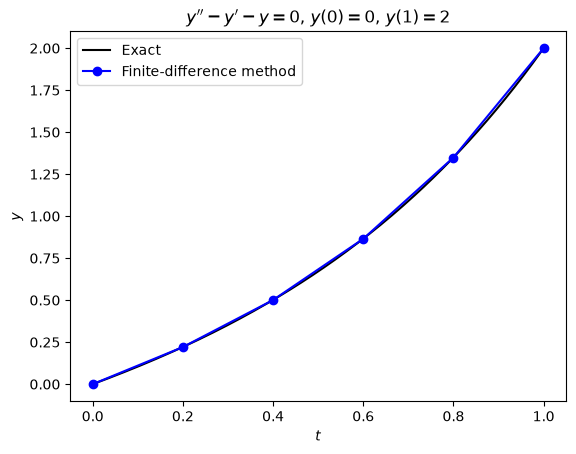

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define BVP parameters
tspan = [0, 1]          # boundaries of the t domain
bvals = [0, 2]          # boundary values
h = 0.2                 # step length

# Compute t values
n = int((tspan[1] - tspan[0]) / h)
t = np.arange(n + 1) * h

# Define linear system
b = np.zeros(n + 1)
b[0] = bvals[0]
b[-1] = bvals[1]
A = np.eye(n + 1)

for i in range(1, n):
    A[i,i-1] = 2 + h
    A[i,i] = -4 - 2 * h**2
    A[i,i+1] = 2 - h

# Solve linear system
y = np.linalg.solve(A, b)

# Define exact solution
def exact(t):
    return (2 * np.exp((1 - np.sqrt(5)) * (t - 1) / 2) * (np.exp(np.sqrt(5) * t) -1)) / (np.exp(np.sqrt(5)) - 1)
    
# Compute exact solution
t_exact = np.linspace(0, tspan[1], 200)
y_exact = exact(t_exact)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t_exact, y_exact, "k-", label="Exact")
plt.plot(t, y, "bo-", label=f"Finite-difference method")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$")
plt.legend()
plt.show()

from myst_nb import glue
glue("bvp_fd_plot", fig, display=False)

## Mesh refinement versus higher-order approximations

The solutions seen in {prf:ref}`bvp-finite-difference-example` seem to show that the finite-difference method produces reasonably accurate results for this boundary value problem. There are two common ways to improve the accuracy of a finite-difference solution:

1. decrease the step length $h$ (increase the number of nodes)
2. use higher-order finite-difference approximations.

In this section we compare these approaches and investigate their effect on the accuracy of the numerical solution. 

Consider the solution of the following BVP using the finite-difference method

$$ y'' + 3ty' + 7y = \cos (2t), \qquad y(0) = 1, \qquad y(3) = 0. $$

Substituting the finite-difference approximations

$$ \begin{align*}
    y''(t_i) &= \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + O(h^2), \\
    y'(t_i) &= \frac{y_{i+1} - y_i}{h} + O(h),
\end{align*} $$

into the differential equation gives

$$ \begin{align*}
    \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + 3t_i \left( \frac{y_{i+1} - y_i}{h}\right) + 7y_i &= \cos(2t_i) + O(h) \\
    y_{i-1} + (-2 - 3ht_i + 7h^2)y_i + (1 + 3ht_i)y_{i+1} &= h^2 \cos(2t_i) + O(h).
\end{align*} $$

Note that although the second derivative approximation is second-order accurate, the forward-difference approximation for $y'$ is only first-order accurate. Consequently, the overall finite-difference scheme has a global error of order $O(h)$.

The linear system is

$$ \begin{align*}
\begin{pmatrix}
    1  \\
    \alpha_1 & \beta_1 & \gamma_1 \\
    & \alpha_2 & \beta_2 & \gamma_2 &  \\
    & & \ddots & \ddots & \ddots \\
    & & & \alpha_{n-1} & \beta_{n-1} & \gamma_{n-1} \\
    & & & & &  1
\end{pmatrix}
    \begin{pmatrix} y_0 \\ y_1 \\ y_2 \\ \vdots \\ y_{n-1} \\ y_n \end{pmatrix}  =
    \begin{pmatrix} 1 \\ h^2 \cos(2t_1) \\ h^2 \cos(2t_2) \\ \vdots \\ h^2 \cos(2t_{n-1}) \\ 0  \end{pmatrix},
\end{align*} $$

where 

$$ \begin{align*}
    \alpha_i &= 1, \\
    \beta_i &= -2 - 3ht_i + 7h^2, \\
    \gamma_i &= 1 + 3ht_i. 
\end{align*} $$

The solution of this tridiagonal linear system is shown in {numref}`bvp-fd-accuracy-figure-1` for $h=0.05$ and $h = 0.005$. Since the method is first-order accurate, reducing the step length by a factor of 10 should reduce the error by approximately a factor of 10.
 
```{glue:figure} bvp_fd_accuracy_plot_1
:name: bvp-fd-accuracy-figure-1
:figwidth: 600

Solutions to the boundary value problem $y'' + 3ty' + 7y = \cos (2t)$, $t \in [0,3]$, $y(0) = 1$, $y(3) = 0$ using first-order finite-difference approximations with $h=0.05$ and $h=0.005$.
```

To obtain a more accurate solution, instead of increasing the number of nodes we could use the [central difference approximation](finite-difference-method-section) to approximate $y'$

$$ y'(t_i) = \frac{y_{i+1} - y_{i-1}}{2h} + O(h^2). $$

Substituting into the differential equation gives

$$ \begin{align*}
    \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + 3t_i\left( \frac{y_{i+1} - y_{i-1}}{2h} \right) + 7y_i &= \cos(2t_i) + O(h^2) \\
    (2 - 3ht_i)y_{i-1} + (-4 + 14h^2)y_i + (2 + 3ht_i)y_{i+1} &= 2h^2 \cos(2t_i) + O(h^2).
\end{align*} $$

Writing as a matrix equation

$$ \begin{align*}
\begin{pmatrix}
    1  \\
    \alpha & \beta & \gamma \\
    & \alpha & \beta & \gamma &  \\
    & & \ddots & \ddots & \ddots \\
    & & & \alpha & \beta & \gamma \\
    & & & & &  1
\end{pmatrix}
    \begin{pmatrix} y_0 \\ y_1 \\ \vdots \\ y_{n-1} \\ y_n \end{pmatrix}  =
    \begin{pmatrix} 1 \\ 2 h^2 \cos(2t_1) \\ \vdots \\ 2 h^2 \cos(2t_{n-1}) \\ 0  \end{pmatrix},
\end{align*} $$

where 

$$ \begin{align*}
    \alpha &= 2 - 3 h t_i, \\
    \beta &= -4 + 14 h^2, \\
    \gamma &= 2 + 3 h t_i.
\end{align*} $$

The solution using the second-order finite difference method with $h=0.05$ has been plotted against the first-order solution using $h=0.05$ and $h=0.005$ in {numref}`bvp-fd-accuracy-figure-2`. The second-order method with $h=0.05$ uses approximately one-tenth as many intervals as the first-order method with $h=0.005$, yet produces a solution of comparable accuracy. This illustrates that increasing the order of the approximation can be more effective than simply refining the mesh.

```{glue:figure} bvp_fd_accuracy_plot_2
:name: bvp-fd-accuracy-figure-2
:figwidth: 600

Solutions to the boundary value problem $y'' + 3ty' + 7y = \cos (2t)$, $t \in [0,3]$, $y(0) = 1$, $y(3) = 0$ using first-order and second-order finite-difference approximations with $h=0.05$ and $h=0.005$.
```

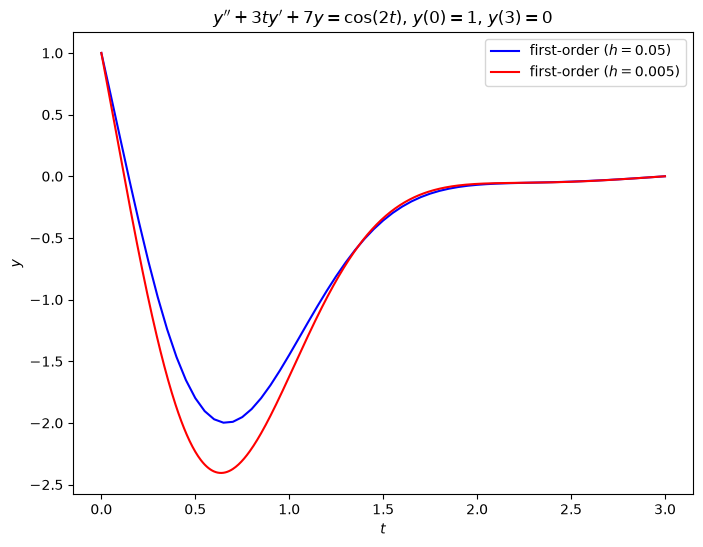

In [2]:
# Define BVP parameters
tspan = [0, 3]         # boundaries of the t domain
bvals = [1, 0]         # boundary values
hvals = [0.05, 0.005]  # step lengths

# Compute the first-order solutions
tsol, ysol = [], []
for h in hvals:

    # Compute the t values
    n = int((tspan[1] - tspan[0]) / h)
    t = np.arange(n + 1) * h

    # Define the linear system
    b = h**2 * np.cos(2 * t)
    b[0] = bvals[0]
    b[-1] = bvals[1]
    A = np.eye(n + 1)

    for i in range(1, n):
        A[i,i-1] = 1
        A[i,i] = - 2 - 3 * h * t[i] + 7 * h**2
        A[i,i+1] = 1 + 3 * h * t[i]

    # Solve linear system
    y = np.linalg.solve(A, b)

    # Append solution to lists
    ysol.append(y)
    tsol.append(t)

# Define linear system (second-order)
h = 0.05
n = int((tspan[1] - tspan[0]) / h)
t = np.arange(n + 1) * h

b = 2 * h**2 * np.cos(2 * t)
b[0] = bvals[0]
b[-1] = bvals[1]
A = np.eye(n + 1)

for i in range(1, n):
    A[i,i-1] = 2 - 3 * h * t[i]
    A[i,i] = -4 + 14 * h**2
    A[i,i+1] = 2 + 3 * h * t[i]

# Solve linear system
y = np.linalg.solve(A, b)

# Append solution to lists
ysol.append(y)
tsol.append(t)

# Plot solution (first-order only)
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(tsol[0], ysol[0], "b-", label=f"first-order ($h={hvals[0]})$")
plt.plot(tsol[1], ysol[1], "r-", label=f"first-order ($h={hvals[1]})$")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y'' + 3ty' + 7y = \\cos(2t)$, $y(0)=1$, $y(3)=0$")
plt.legend()
plt.show()

from myst_nb import glue
glue("bvp_fd_accuracy_plot_1", fig, display=False)

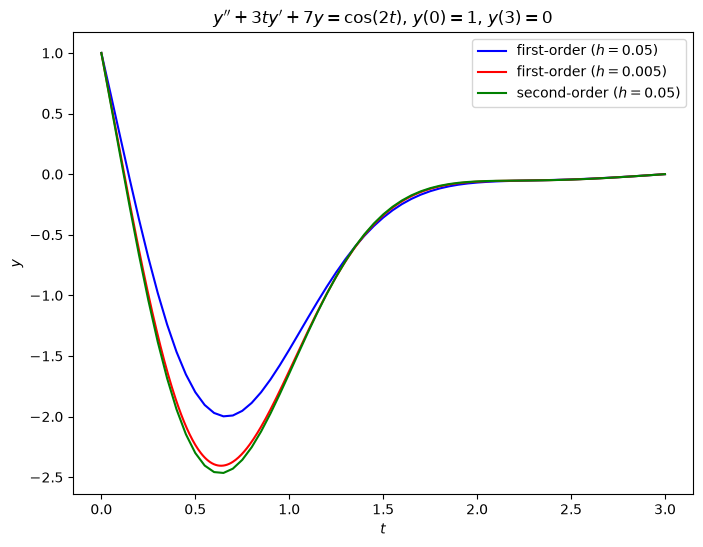

In [3]:
# Plot solution (first and second-order)
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(tsol[0], ysol[0], "b-", label=f"first-order ($h={hvals[0]}$)")
plt.plot(tsol[1], ysol[1], "r-", label=f"first-order ($h={hvals[1]}$)")
plt.plot(tsol[2], ysol[2], "g-", label=f"second-order ($h={h}$)")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y'' + 3ty' + 7y = \\cos(2t)$, $y(0)=1$, $y(3)=0$")
plt.legend()
plt.show()

from myst_nb import glue
glue("bvp_fd_accuracy_plot_2", fig, display=False)